# Import libaries

In [29]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# 0. Load data

In [24]:
# Download latest version
path = kagglehub.dataset_download(
    "vjchoudhary7/customer-segmentation-tutorial-in-python",
    output_dir="data"
)

DATA_DIR = Path("data")
DATA_FILE = DATA_DIR / "Mall_Customers.csv"

print(f"Dataset: {DATA_FILE}")

Dataset: data\Mall_Customers.csv


# 1. Data inspection
- shape
- basic information about rows and columns
- null values
- duplicates

In [25]:
df = pd.read_csv(DATA_FILE)

print("=" * 50)
print("DATA INSPECTION")
print("=" * 50)

# Dataset shape
print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Column information
print("\n" + "-" * 50)
print("COLUMN INFORMATION")
print("-" * 50)

df.info()

# Missing values
print("\n" + "-" * 50)
print("MISSING VALUES")
print("-" * 50)

missing_values = df.isnull().sum()

if missing_values.sum() == 0:
    print("No missing values found.")
else:
    print(missing_values[missing_values > 0])

# Duplicates
print("\n" + "-" * 50)
print("DUPLICATE ROWS")
print("-" * 50)

duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

print("\n" + "=" * 50)
print("INSPECTION COMPLETE")
print("=" * 50)

DATA INSPECTION

Dataset shape: 200 rows × 5 columns

--------------------------------------------------
COLUMN INFORMATION
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

--------------------------------------------------
MISSING VALUES
--------------------------------------------------
No missing values found.

--------------------------------------------------
DUPLICATE ROWS
--------------------------------------------------
Number of duplicate rows: 0

INSPECTION COMPLETE


# 2. Evaluate data analysis
- describe statistics
- numerical features distribution (age, annual income, spending score)
- categorical features distribution (gender)
- outlier analysis
- correlation analysis

## 2.1 Describe statistics

In [28]:
print("-" * 50)
print("DESCRIPTIVE STATISTICS")
print("-" * 50)

display(df.describe())

--------------------------------------------------
DESCRIPTIVE STATISTICS
--------------------------------------------------


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 2.2 Numerical features distribution

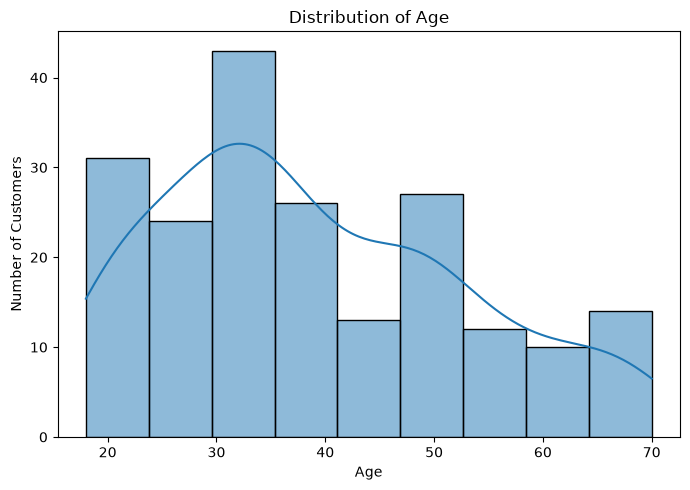

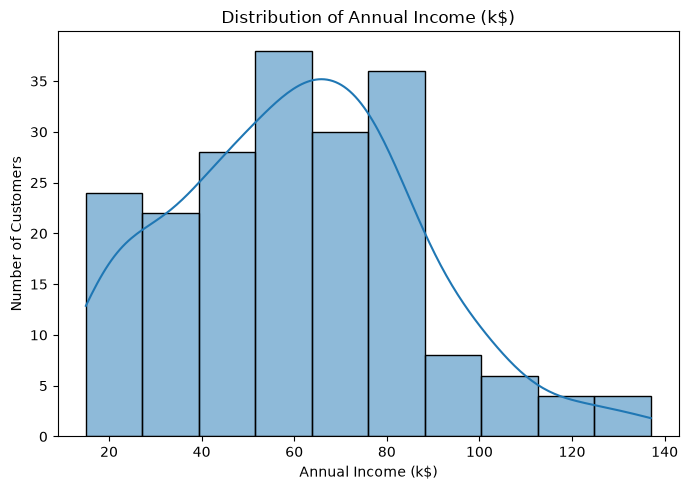

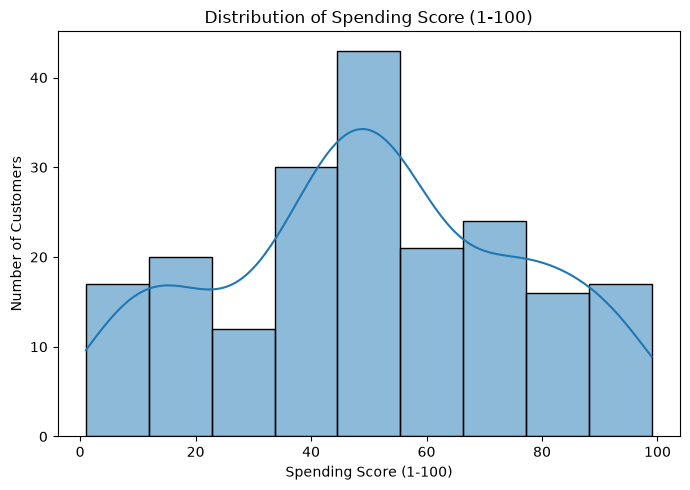

In [43]:
numeric_columns = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

for column in numeric_columns:
    plt.figure(figsize=(7,5))

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.tight_layout()
    plt.show()

### Observation
- Age Distribution => The distribution is slightly right-skewed, with most customers aged 30–35. The mean age is around 39, with a standard deviation of 14, while 75% of customers are below 49 years old.
- Annual Income => The mean annual income is approximately $60k, with a standard deviation of $26k. Around 75% of customers have an annual income below $78k, showing a relatively wide income range.
- Spending Score => The mean spending score is approximately 50, with a standard deviation of 26. The distribution is fairly symmetric, with customers spread across a wide range of spending scores.

## 2.3 Categorical features distribution

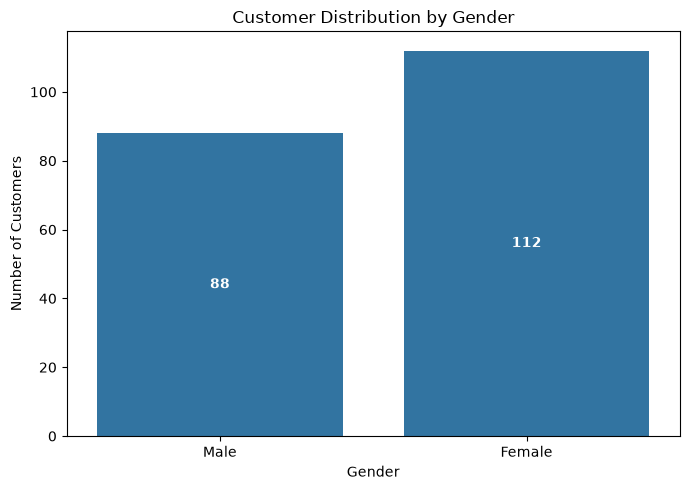

In [41]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Gender",
)

ax.bar_label(
    ax.containers[0],
    label_type="center",
    color="white",
    fontweight="bold"
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.show()

## 2.4 Outlier analysis

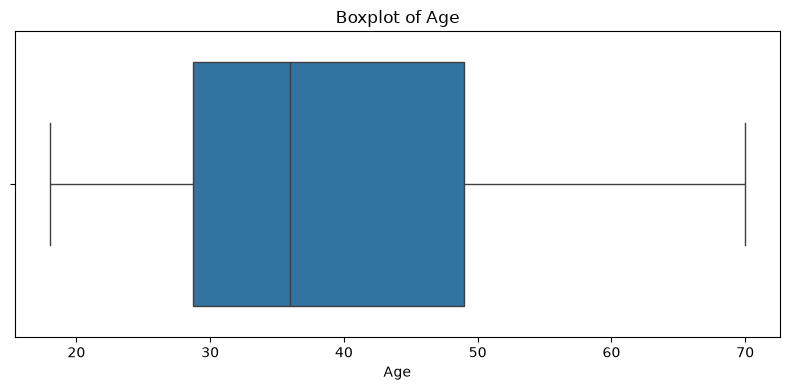

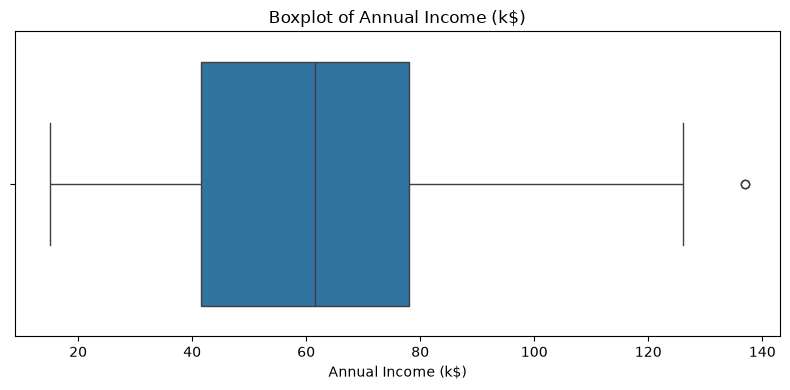

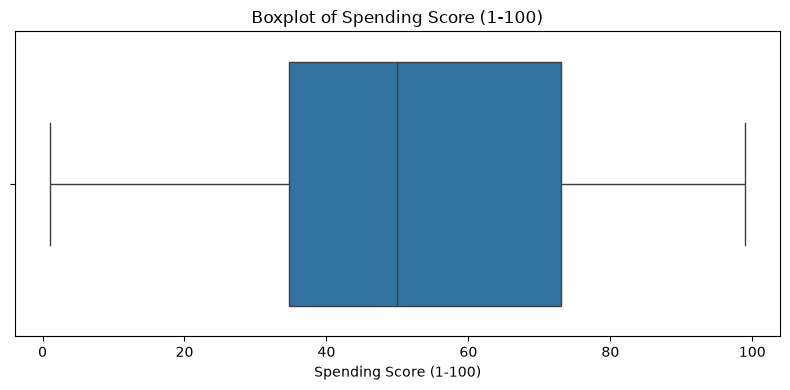

In [44]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(
        x=df[column]
    )
    
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

### Observation
- Age => The boxplot shows a relatively wide age range, with no significant outliers.
- Annual Income => Customers have a relatively wide range of annual incomes, with some higher-income customers but no extreme outliers.
- Spending Score → The spending score is relatively well distributed, with no significant outliers.

## 2.5 Correlation Analysis

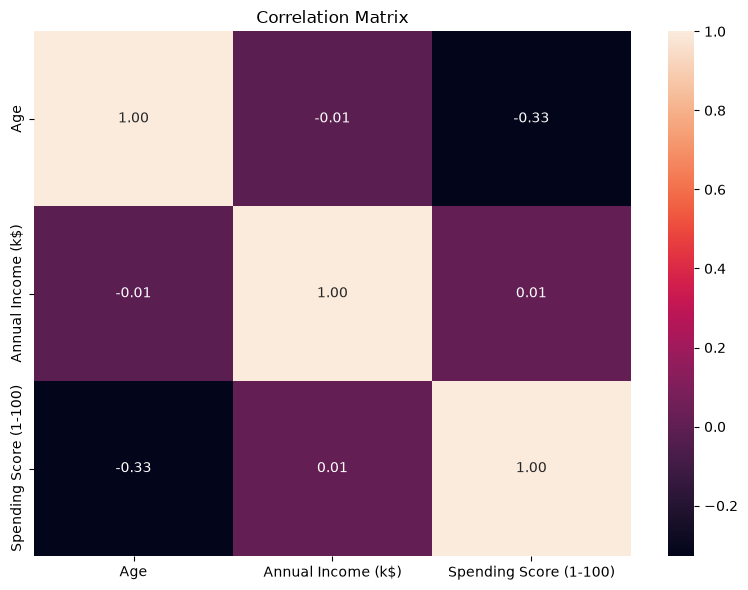

In [50]:
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Observation
- Age & Spending Score => Moderate negative correlation (-0.33), suggesting that older customers tend to have slightly lower spending scores.
- Age & Annual Income => Almost no correlation (-0.01), indicating no meaningful linear relationship between age and income.
- Annual Income & Spending Score => Almost no correlation (0.01), suggesting that income alone does not determine customers' spending behavior.